In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('house.csv')
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [4]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

(1460, 81)

In [7]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [8]:
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

In [11]:
df = df[['GrLivArea', 'YearBuilt', 'GarageCars', 
         'TotalBsmtSF', 'FullBath', 'OverallQual', 'Neighborhood', 'SalePrice']]

In [13]:
df.to_csv('data_clean.csv', index=False)

In [15]:
count_nei = df['Neighborhood'].nunique()
print(f'Количество уникальных районов: {count_nei}')

Количество уникальных районов: 25


In [18]:
df.groupby('Neighborhood')['SalePrice'].mean().round().sort_values(ascending=False).head(5)

Neighborhood
NoRidge    335295.0
NridgHt    316271.0
StoneBr    310499.0
Timber     242247.0
Veenker    238773.0
Name: SalePrice, dtype: float64

In [23]:
count_year = (df['YearBuilt'] > 2000).sum()
print(f'Количество домов построенных после 2000-года: {count_year}')

Количество домов построенных после 2000-года: 364


In [24]:
df.groupby('OverallQual')['GrLivArea'].mean().round()

OverallQual
1      619.0
2      573.0
3     1119.0
4     1107.0
5     1251.0
6     1466.0
7     1704.0
8     1948.0
9     2078.0
10    3001.0
Name: GrLivArea, dtype: float64

In [33]:
count_zero = (df['TotalBsmtSF'] == 0).sum()
count_zero

np.int64(37)

In [34]:
total_house = df['TotalBsmtSF'].shape[0]

In [35]:
print(f'{round((count_zero * 100) / total_house, 2)} %')

2.53 %


In [36]:
df.groupby('GarageCars')['SalePrice'].mean().round()

GarageCars
0    103317.0
1    128117.0
2    183852.0
3    309636.0
4    192656.0
Name: SalePrice, dtype: float64

In [38]:
count_bath = (df['FullBath'] > 2).sum()
print(f'Количество домов, которые имеют больше 2-х ванных комнат: {count_bath}')

Количество домов, которые имеют больше 2-х ванных комнат: 33


In [40]:
df['Neighborhood'].value_counts().head(1)

Neighborhood
NAmes    225
Name: count, dtype: int64

In [41]:
new_df = df[['GrLivArea', 'TotalBsmtSF', 'OverallQual', 'GarageCars', 'SalePrice']]
new_df.corr()

,GrLivArea,TotalBsmtSF,OverallQual,GarageCars,SalePrice
GrLivArea,1.000000,0.454868,0.593007,0.467247,0.708624
TotalBsmtSF,0.454868,1.000000,0.537808,0.434585,0.613581
OverallQual,0.593007,0.537808,1.000000,0.600671,0.790982
GarageCars,0.467247,0.434585,0.600671,1.000000,0.640409
SalePrice,0.708624,0.613581,0.790982,0.640409,1.000000


In [76]:
mean_sale = (df.groupby('GarageCars', as_index=False)['SalePrice'].mean())
mean_sale['SalePrice'] = mean_sale['SalePrice'].round()

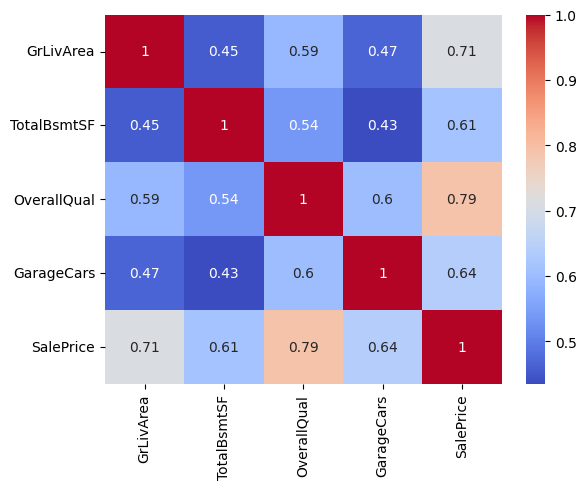

In [42]:
sns.heatmap(new_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [45]:
rating_df = df.groupby('Neighborhood')['SalePrice'].mean().round().sort_values(ascending=False)
rating_df.to_csv('rating.csv')

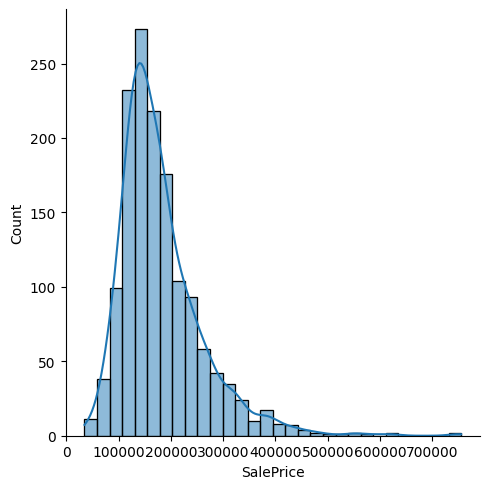

In [47]:
sns.displot(df['SalePrice'], bins=30, kde=True)
plt.show()

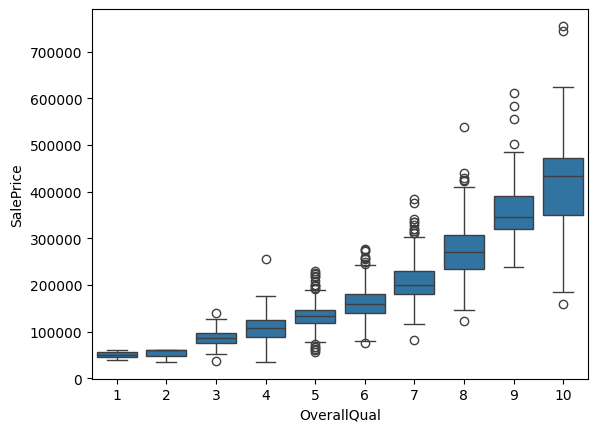

In [56]:
sns.boxplot(data=df, x='OverallQual', y='SalePrice')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28932\1059692269.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='SalePrice', y='Neighborhood', split=True, palette=['red', 'aqua'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28932\1059692269.py:2: UserWarning: 
The palette list has fewer values (2) than needed (25) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(data=df, x='SalePrice', y='Neighborhood', split=True, palette=['red', 'aqua'])


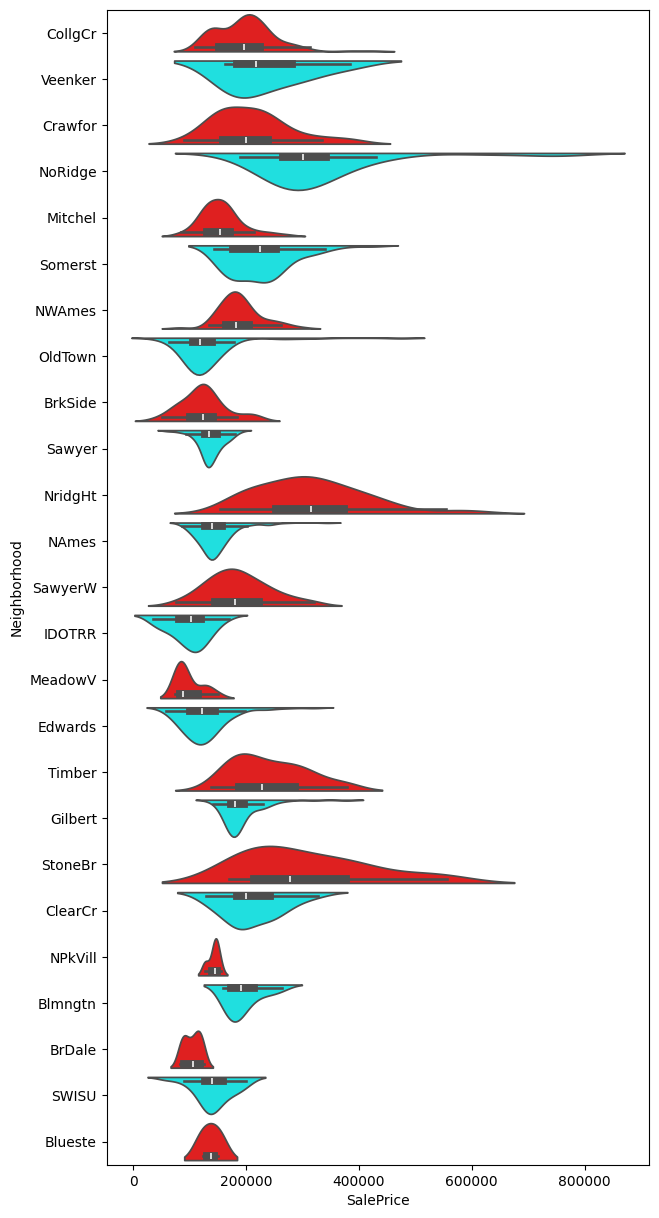

In [66]:
plt.figure(figsize=(7, 15))
sns.violinplot(data=df, x='SalePrice', y='Neighborhood', split=True, palette=['red', 'aqua'])
plt.show()

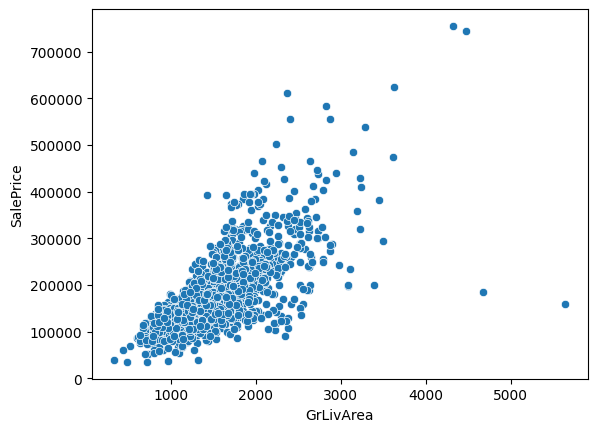

In [67]:
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice')
plt.show()

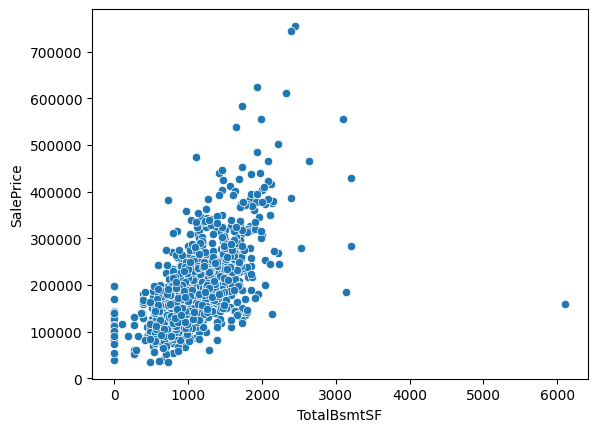

In [68]:
sns.scatterplot(data=df, x='TotalBsmtSF', y='SalePrice')
plt.show()

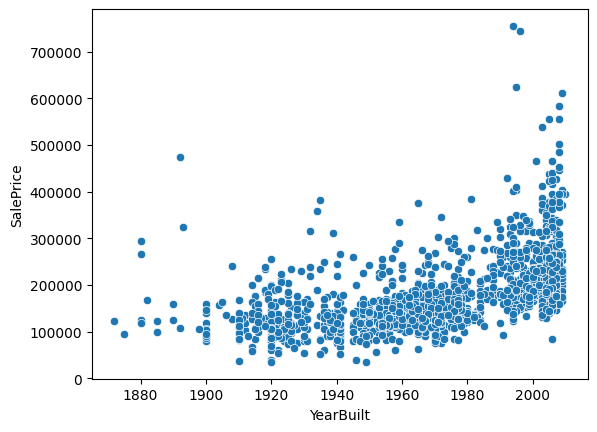

In [69]:
sns.scatterplot(data=df, x='YearBuilt', y='SalePrice')
plt.show()

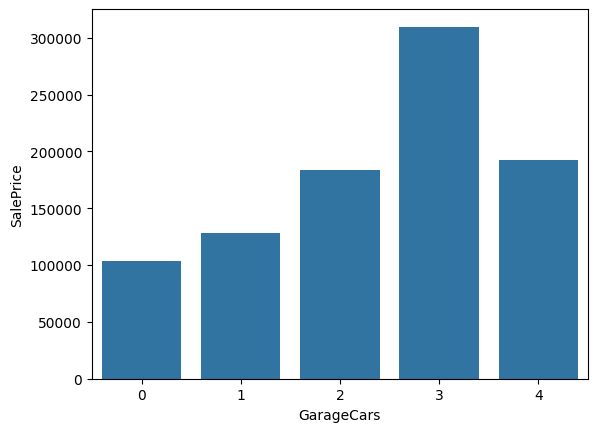

In [77]:
sns.barplot(data=mean_sale, x='GarageCars', y='SalePrice')
plt.show()

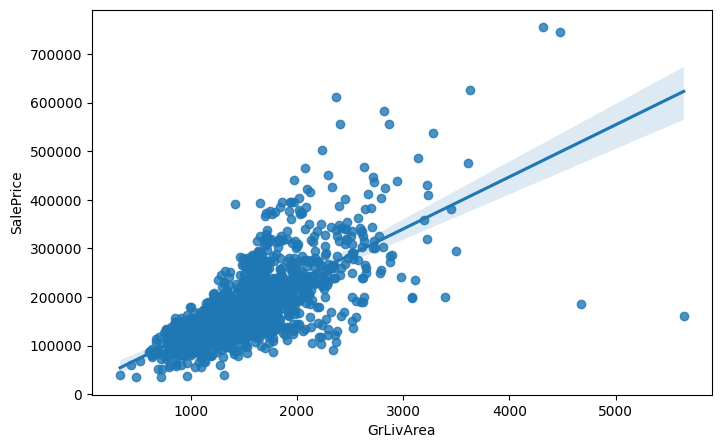

In [78]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='GrLivArea', y='SalePrice')
plt.show()

In [79]:
cols = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'OverallQual', 'Garage]

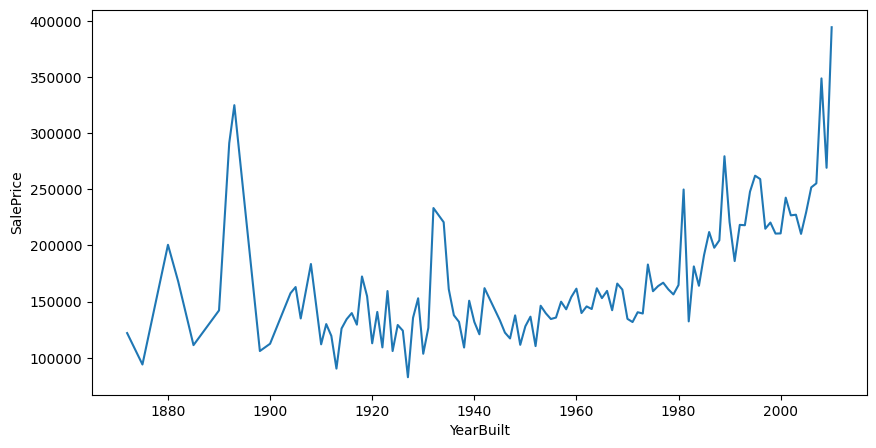

In [81]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=year_mean, x='YearBuilt', y='SalePrice')
plt.show()